# 🧠 Simulación de un sistema CBR médico

Este notebook simula un sistema de razonamiento basado en casos (Case-Based Reasoning, CBR) en el contexto médico. El usuario puede ingresar síntomas, y el sistema buscará el caso más parecido en la base de datos. También se puede guardar el nuevo caso si se desea.

Además, se incluye una visualización de los síntomas más frecuentes y un análisis estadístico básico de los casos existentes.


### 1. Imports 

In [2]:
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display, Markdown

### 2. Base de datos de casos médicos

In [3]:
casos_medicos = [
    {"id": 1, "sintomas": ["fiebre alta", "tos seca", "dolor de cabeza", "cansancio"], "diagnostico": "Gripe común", "tratamiento": ["reposo", "paracetamol", "líquidos"]},
    {"id": 2, "sintomas": ["dolor abdominal intenso", "fiebre", "vómitos"], "diagnostico": "Apendicitis", "tratamiento": ["cirugía", "antibióticos"]},
    {"id": 3, "sintomas": ["tos con flema", "dificultad para respirar", "dolor en el pecho"], "diagnostico": "Bronquitis", "tratamiento": ["jarabe expectorante", "inhalador", "reposo"]},
    {"id": 4, "sintomas": ["dolor de garganta", "fiebre moderada", "dificultad para tragar"], "diagnostico": "Faringitis", "tratamiento": ["ibuprofeno", "gárgaras", "líquidos"]},
    {"id": 5, "sintomas": ["dolor muscular", "fiebre leve", "congestión nasal"], "diagnostico": "Resfriado común", "tratamiento": ["reposo", "analgésicos", "descongestionante"]},
    {"id": 6, "sintomas": ["dolor en el pecho", "sudoración", "dificultad para respirar", "náuseas"], "diagnostico": "Infarto agudo de miocardio", "tratamiento": ["hospitalización urgente", "anticoagulantes"]},
    {"id": 7, "sintomas": ["dolor de cabeza intenso", "sensibilidad a la luz", "náuseas"], "diagnostico": "Migraña", "tratamiento": ["analgésicos específicos", "descanso en lugar oscuro"]},
    {"id": 8, "sintomas": ["picor en la piel", "ronchas", "hinchazón"], "diagnostico": "Alergia cutánea", "tratamiento": ["antihistamínicos", "crema tópica"]},
    {"id": 9, "sintomas": ["dolor lumbar", "rigidez", "dificultad para moverse"], "diagnostico": "Lumbalgia", "tratamiento": ["reposo", "fisioterapia", "analgésicos"]},
    {"id": 10, "sintomas": ["dolor ocular", "visión borrosa", "sensibilidad a la luz"], "diagnostico": "Conjuntivitis", "tratamiento": ["colirio", "higiene ocular"]}
]

### 3. Visualización de síntomas más frecuentes

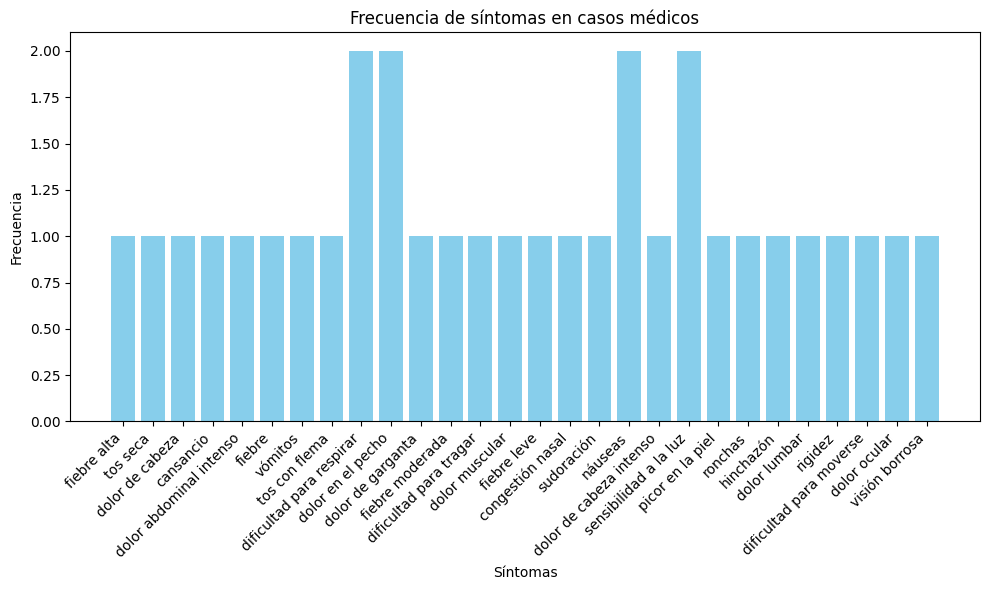

In [4]:
todos_sintomas = [s for caso in casos_medicos for s in caso["sintomas"]]
frecuencia = Counter(todos_sintomas)

plt.figure(figsize=(10, 6))
plt.bar(frecuencia.keys(), frecuencia.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Frecuencia de síntomas en casos médicos")
plt.xlabel("Síntomas")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### 4. Análisis estadístico básico

In [5]:
num_casos = len(casos_medicos)
sintomas_unicos = set(todos_sintomas)
promedio_sintomas = sum(len(c["sintomas"]) for c in casos_medicos) / num_casos

print(f"Número total de casos: {num_casos}")
print(f"Número de síntomas únicos: {len(sintomas_unicos)}")
print(f"Promedio de síntomas por caso: {promedio_sintomas:.2f}")


Número total de casos: 10
Número de síntomas únicos: 28
Promedio de síntomas por caso: 3.20


### 5. Función para comparar síntomas

In [6]:
# Función que calcula la cantidad de síntomas en común entre dos listas
def comparar_sintomas(sintomas_usuario, sintomas_caso):
    return len(set(sintomas_usuario) & set(sintomas_caso))

### 6. Entrada del usuario

In [7]:
entrada = input("Introduce los síntomas separados por comas: ").lower()
sintomas_usuario = [s.strip() for s in entrada.split(",")]
print(sintomas_usuario)

['dolor de cabeza intenso', 'dolor abdominal intenso']


In [8]:
# Ejemplo de entrada correcta para alergia cutánea:
# Debes escribir: picor en la piel, ronchas, hinchazón
# (SIN comillas)

print("Ejemplo correcto para alergia cutánea:")
print("Entrada: picor en la piel, ronchas, hinchazón")
print("NO uses comillas en los síntomas")

Ejemplo correcto para alergia cutánea:
Entrada: picor en la piel, ronchas, hinchazón
NO uses comillas en los síntomas


### 7. Búsqueda del caso más parecido

In [9]:
mejor_caso = None
max_similitud = -1

# Miramos todos los casos
for caso in casos_medicos:
    # Calculamos la similitud
    similitud = comparar_sintomas(sintomas_usuario, caso["sintomas"])
    print(f"{caso['diagnostico']} similitud: {similitud}")
    #  Mirmos si es el mejor caso
    if similitud > max_similitud:
        max_similitud = similitud
        mejor_caso = caso
        print(f"\tNueva mejor coincidencia encontrada: {mejor_caso['diagnostico']}")

Gripe común similitud: 0
	Nueva mejor coincidencia encontrada: Gripe común
Apendicitis similitud: 1
	Nueva mejor coincidencia encontrada: Apendicitis
Bronquitis similitud: 0
Faringitis similitud: 0
Resfriado común similitud: 0
Infarto agudo de miocardio similitud: 0
Migraña similitud: 1
Alergia cutánea similitud: 0
Lumbalgia similitud: 0
Conjuntivitis similitud: 0


In [10]:
# Diagnóstico detallado del problema
print("=" * 60)
print("ANÁLISIS DETALLADO DEL EMPATE")
print("=" * 60)

print(f"\nSíntomas que ingresaste: {sintomas_usuario}")

# Veamos específicamente la comparación con Gripe común y Alergia cutánea
gripe = casos_medicos[0]  # ID 1: Gripe común  
alergia = casos_medicos[7]  # ID 8: Alergia cutánea

print(f"\nGRIPE COMÚN (4 síntomas):")
print(f"   Síntomas BD: {gripe['sintomas']}")
similitud_gripe = comparar_sintomas(sintomas_usuario, gripe["sintomas"])
coincidencias_gripe = set(sintomas_usuario) & set(gripe['sintomas'])
print(f"   Similitud: {similitud_gripe}")
print(f"   Coincidencias exactas: {coincidencias_gripe}")

print(f"\nALERGIA CUTÁNEA (3 síntomas):")
print(f"   Síntomas BD: {alergia['sintomas']}")
similitud_alergia = comparar_sintomas(sintomas_usuario, alergia["sintomas"])
coincidencias_alergia = set(sintomas_usuario) & set(alergia['sintomas'])
print(f"   Similitud: {similitud_alergia}")
print(f"   Coincidencias exactas: {coincidencias_alergia}")

print(f"\nANÁLISIS DEL EMPATE:")
if similitud_gripe == similitud_alergia:
    print(f"   EMPATE detectado: {similitud_gripe} = {similitud_alergia}")
    print(f"   Alergia cutánea es MÁS ESPECÍFICA: {len(alergia['sintomas'])} < {len(gripe['sintomas'])} síntomas")
    print(f"   Porcentaje de coincidencia:")
    print(f"      - Gripe: {similitud_gripe}/{len(gripe['sintomas'])} = {similitud_gripe/len(gripe['sintomas'])*100:.1f}%")
    print(f"      - Alergia: {similitud_alergia}/{len(alergia['sintomas'])} = {similitud_alergia/len(alergia['sintomas'])*100:.1f}%")
    print(f"   El algoritmo elige el primer caso encontrado (Gripe común)")
elif similitud_gripe > similitud_alergia:
    print(f"   Gripe gana: {similitud_gripe} > {similitud_alergia}")
else:
    print(f"   Alergia gana: {similitud_alergia} > {similitud_gripe}")

print("=" * 60)

ANÁLISIS DETALLADO DEL EMPATE

Síntomas que ingresaste: ['dolor de cabeza intenso', 'dolor abdominal intenso']

GRIPE COMÚN (4 síntomas):
   Síntomas BD: ['fiebre alta', 'tos seca', 'dolor de cabeza', 'cansancio']
   Similitud: 0
   Coincidencias exactas: set()

ALERGIA CUTÁNEA (3 síntomas):
   Síntomas BD: ['picor en la piel', 'ronchas', 'hinchazón']
   Similitud: 0
   Coincidencias exactas: set()

ANÁLISIS DEL EMPATE:
   EMPATE detectado: 0 = 0
   Alergia cutánea es MÁS ESPECÍFICA: 3 < 4 síntomas
   Porcentaje de coincidencia:
      - Gripe: 0/4 = 0.0%
      - Alergia: 0/3 = 0.0%
   El algoritmo elige el primer caso encontrado (Gripe común)


De la Gripe común, tenemos anotados 4 sintomas, y le hemos dado 2 de ellos,..... pero la alergia cutánea solo tiene 3 síntomas y le hemos dado 2 de ellos... Deberia elegirme la alergia cutánea en vez de la gripe común?
Mejoramos el resultado?

In [11]:
mejor_caso = None
max_similitud = -1
mejor_especificidad = float('inf')  # Para casos con menos síntomas (más específicos)

for caso in casos_medicos:
    similitud = comparar_sintomas(sintomas_usuario, caso["sintomas"])
    print(f"{caso['diagnostico']}: similitud = {similitud}, síntomas = {len(caso['sintomas'])}")
    
    # Mejorar criterio: si hay empate, elegir el más específico (menos síntomas)
    es_mejor = (similitud > max_similitud or 
                (similitud == max_similitud and len(caso["sintomas"]) < mejor_especificidad))
    
    if es_mejor:
        max_similitud = similitud
        mejor_especificidad = len(caso["sintomas"])
        mejor_caso = caso
        print(f"  \033[92mNueva mejor coincidencia:\033[0m {mejor_caso['diagnostico']} (similitud: {similitud}, especificidad: {mejor_especificidad})")

print(f"\n\033[93mGANADOR:\033[0m {mejor_caso['diagnostico']} (similitud: {max_similitud}, síntomas: {mejor_especificidad})")


Gripe común: similitud = 0, síntomas = 4
  Nueva mejor coincidencia: Gripe común (similitud: 0, especificidad: 4)
Apendicitis: similitud = 1, síntomas = 3
  Nueva mejor coincidencia: Apendicitis (similitud: 1, especificidad: 3)
Bronquitis: similitud = 0, síntomas = 3
Faringitis: similitud = 0, síntomas = 3
Resfriado común: similitud = 0, síntomas = 3
Infarto agudo de miocardio: similitud = 0, síntomas = 4
Migraña: similitud = 1, síntomas = 3
Alergia cutánea: similitud = 0, síntomas = 3
Lumbalgia: similitud = 0, síntomas = 3
Conjuntivitis: similitud = 0, síntomas = 3

GANADOR: Apendicitis (similitud: 1, síntomas: 3)


In [12]:
# Diagnóstico detallado del problema
print("=" * 60)
print("ANÁLISIS DETALLADO DEL EMPATE")
print("=" * 60)

print(f"\nSíntomas que ingresaste: {sintomas_usuario}")

# Veamos específicamente la comparación con Gripe común y Alergia cutánea
gripe = casos_medicos[0]  # ID 1: Gripe común  
alergia = casos_medicos[7]  # ID 8: Alergia cutánea

print(f"\nGRIPE COMÚN (4 síntomas):")
print(f"  - Síntomas BD: {gripe['sintomas']}")
similitud_gripe = comparar_sintomas(sintomas_usuario, gripe["sintomas"])
coincidencias_gripe = set(sintomas_usuario) & set(gripe['sintomas'])
print(f"  - Similitud: {similitud_gripe}")
print(f"  - Coincidencias exactas: {coincidencias_gripe}")

print(f"\nALERGIA CUTÁNEA (3 síntomas):")
print(f"  - Síntomas BD: {alergia['sintomas']}")
similitud_alergia = comparar_sintomas(sintomas_usuario, alergia["sintomas"])
coincidencias_alergia = set(sintomas_usuario) & set(alergia['sintomas'])
print(f"  - Similitud: {similitud_alergia}")
print(f"  - Coincidencias exactas: {coincidencias_alergia}")

print(f"\nANÁLISIS DEL EMPATE:")
if similitud_gripe == similitud_alergia:
    print(f"   EMPATE detectado: {similitud_gripe} = {similitud_alergia}")
    print(f"   Alergia cutánea es MÁS ESPECÍFICA: {len(alergia['sintomas'])} < {len(gripe['sintomas'])} síntomas")
    print(f"   Porcentaje de coincidencia:")
    print(f"      - Gripe: {similitud_gripe}/{len(gripe['sintomas'])} = {similitud_gripe/len(gripe['sintomas'])*100:.1f}%")
    print(f"      - Alergia: {similitud_alergia}/{len(alergia['sintomas'])} = {similitud_alergia/len(alergia['sintomas'])*100:.1f}%")
    print(f"   Con el nuevo algoritmo, debería ganar: Alergia cutánea")
else:
    print(f"  - No hay empate que analizar.")
print("=" * 60)

ANÁLISIS DETALLADO DEL EMPATE

Síntomas que ingresaste: ['dolor de cabeza intenso', 'dolor abdominal intenso']

GRIPE COMÚN (4 síntomas):
  - Síntomas BD: ['fiebre alta', 'tos seca', 'dolor de cabeza', 'cansancio']
  - Similitud: 0
  - Coincidencias exactas: set()

ALERGIA CUTÁNEA (3 síntomas):
  - Síntomas BD: ['picor en la piel', 'ronchas', 'hinchazón']
  - Similitud: 0
  - Coincidencias exactas: set()

ANÁLISIS DEL EMPATE:
   EMPATE detectado: 0 = 0
   Alergia cutánea es MÁS ESPECÍFICA: 3 < 4 síntomas
   Porcentaje de coincidencia:
      - Gripe: 0/4 = 0.0%
      - Alergia: 0/3 = 0.0%
   Con el nuevo algoritmo, debería ganar: Alergia cutánea


### 8. Visualización del resultado

In [13]:
if mejor_caso:
    print(f"Caso más parecido encontrado:\n" + 
          f"Síntomas: {', '.join(mejor_caso['sintomas'])}\n" +
          f"Diagnóstico: {mejor_caso['diagnostico']}\n" +
          f"Tratamiento: {', '.join(mejor_caso['tratamiento'])}")
else:
    print("No se encontró un caso similar.")


Caso más parecido encontrado:
Síntomas: dolor abdominal intenso, fiebre, vómitos
Diagnóstico: Apendicitis
Tratamiento: cirugía, antibióticos


### 9. Retención del nuevo caso

In [14]:

guardar = input("¿Deseas guardar este nuevo caso en la base de datos? (sí/no): ").lower()

if guardar == "sí" or guardar == "si":
    nuevo_id = len(casos_medicos) + 1
    nuevo_caso = {
        "id": nuevo_id,
        "sintomas": sintomas_usuario,
        "diagnostico": "Pendiente", # Diagnóstico por determinar
        "tratamiento": ["Pendiente"] # Tratamiento por determinar
    }
    casos_medicos.append(nuevo_caso)
    print(f"Nuevo caso guardado con ID {nuevo_id}.")


---

# Ejercicios

1. 🧰 Reparación de electrodomésticos <br><br>
**Caso:** <br>
    - Una lavadora no centrifuga. <br>
    - Solución anterior: Cambiar el condensador. <br>
    - Nuevo caso: Lavadora no centrifuga, hace ruido → ¿Es el mismo problema o uno nuevo? <br><br><br>

2. 🧑‍🍳 Cocina y recetas <br><br>
**Caso:** <br>
    - Tortilla de patatas con 3 huevos y 2 patatas → resultado seco. <br>
    - Solución anterior: Añadir cebolla y 1 huevo más. <br>
    - Nuevo caso: Tortilla con 4 huevos, sin cebolla → ¿Qué ajustar? <br><br><br>

3. 🧑‍💼 Atención al cliente <br><br>
**Caso:** <br>
    - Cliente se queja de lentitud en la app móvil. <br>
    - Solución anterior: Sugerir borrar caché y actualizar. <br>
    - Nuevo caso: Cliente con mismo problema pero en Android → ¿Aplicar misma solución? <br><br><br>

4. 🚗 Diagnóstico de averías en coches <br><br>
**Caso:** <br>
    - Coche no arranca, batería descargada. <br>
    - Solución anterior: Reemplazo de batería. <br>
    - Nuevo caso: Coche no arranca, luces encendidas → ¿Es batería o alternador? <br><br><br>

5. 🧑‍🏫 Tutoría educativa <br><br>
**Caso:** <br>
    - Estudiante con bajo rendimiento en matemáticas por falta de práctica. <br>
    - Solución anterior: Plan de ejercicios diarios. <br>
    - Nuevo caso: Estudiante con bajo rendimiento pero con ansiedad → ¿Misma solución o adaptada? <br><br><br>